In [9]:
from src.utils import DataType, data_config_map, generate_grid
import matplotlib.pyplot as plt
import torch
import numpy as np

In [10]:
def visualize_data(data_type: DataType, cheby:bool, train_a, test_a, train_u, test_u):

    # Burgers Plot
    if data_config_map[data_type].d == 1:

        # Establish figure subplots and titles 
        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        axs[0][0].set_title(f"train_a")
        axs[0][1].set_title(f"train_u")
        axs[1][0].set_title(f"test_a")
        axs[1][1].set_title(f"test_u")

        grid = generate_grid(train_a.shape[0], cheby)

        markevery = 128
        if data_type == DataType.HELMHOLTZ:
            axs[0][0].plot(grid, train_a, 'o', ls='-', ms=4, markevery=markevery)
            axs[0][1].plot(grid, train_u[..., 0:1], 'o', ls='-', ms=4, markevery=markevery)
            axs[0][1].plot(grid, train_u[..., 1:2], 'o', ls='-.', ms=4, markevery=markevery)
            axs[1][0].plot(grid, test_a, 'o', ls='-', ms=4, markevery=markevery)
            axs[1][1].plot(grid, test_u[..., 0:1], 'o', ls='-', ms=4, markevery=markevery)
            axs[1][1].plot(grid, test_u[..., 1:2], 'o', ls='-.', ms=4, markevery=markevery)
            
        else:
            axs[0][0].plot(grid, train_a, 'o', ls='-', ms=4, markevery=markevery)
            axs[0][1].plot(grid, train_u, 'o', ls='-', ms=4, markevery=markevery)
            axs[1][0].plot(grid, test_a, 'o', ls='-', ms=4, markevery=markevery)
            axs[1][1].plot(grid, test_u, 'o', ls='-', ms=4, markevery=markevery)

    elif data_type == DataType.DARCY:
        # Establish figure subplots and titles 

        grid = generate_grid(train_a.shape[0:2], cheby)
        if cheby:
            grid *= 2
            grid -= 1

        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        axs[0][0].set_title(f"train_a")
        axs[0][1].set_title(f"train_u")
        axs[1][0].set_title(f"test_a")
        axs[1][1].set_title(f"test_u")


        axs[0][0].pcolormesh(grid[..., 0], grid[..., 1], train_a[..., 0], cmap='viridis', linewidth=0.5)
        axs[0][1].pcolormesh(grid[..., 0], grid[..., 1], train_u[..., 0], cmap='viridis', linewidth=0.5)
        axs[1][0].pcolormesh(grid[..., 0], grid[..., 1], test_a[..., 0], cmap='viridis', linewidth=0.5)
        axs[1][1].pcolormesh(grid[..., 0], grid[..., 1], test_u[..., 0], cmap='viridis', linewidth=0.5)

    elif data_type == DataType.HELMHOLTZ_2D:
        # Establish figure subplots and titles 
        fig, axs = plt.subplots(2, 3, figsize=(12, 10))
        axs[0][0].set_title(f"train_a")
        axs[0][1].set_title(f"train_u_real")
        axs[0][2].set_title(f"train_u_imag")
        axs[1][0].set_title(f"test_a")
        axs[1][1].set_title(f"test_u_real")
        axs[1][2].set_title(f"test_u_imag")

        axs[0][0].imshow(train_a)
        axs[0][1].imshow(train_u[..., 0])
        axs[0][2].imshow(train_u[..., 1])
        axs[1][0].imshow(test_a)
        axs[1][1].imshow(test_u[..., 0])
        axs[1][2].imshow(test_u[..., 1])


    plt.show()

train_a shape:  torch.Size([2048, 1])
test_a shape:  torch.Size([2048, 1])
train_u shape:  torch.Size([2048, 1])
test_u shape:  torch.Size([2048, 1])


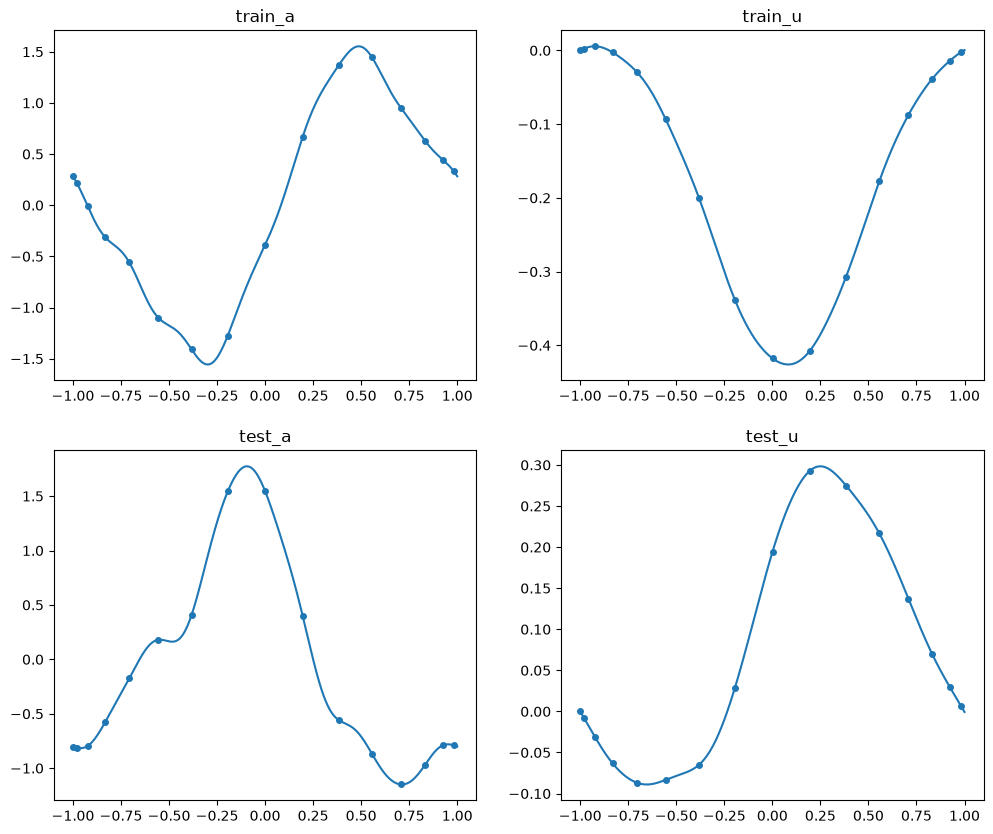

In [ ]:
data_type = DataType.ODE1D16
cheby = True

data_config = data_config_map.get(data_type)
pth = data_config.pth if cheby is False else data_config.cheby_pth

data = torch.load(pth, mmap=True)

train_a, test_a = data["a"][0], data["a"][-1]
train_u, test_u = data["u"][0], data["u"][-1]

print("train_a shape: ", train_a.shape)
print("test_a shape: ", test_a.shape)
print("train_u shape: ", train_u.shape)
print("test_u shape: ", test_u.shape)

visualize_data(data_type=data_type, cheby=cheby, train_a=train_a, train_u=train_u, test_a=test_a, test_u=test_u)

In [ ]:
def visualize_cgl_vs_unif(data_type: DataType, unif_a, unif_u, cgl_a, cgl_u):
    if data_type == DataType.BURGERS:
        """Plots the permeability and solution fields for a given sample on both grids."""
        fig, axs = plt.subplots(2, 2, figsize=(10, 8))

        unif_grid = generate_grid(unif_a.shape[0:1], False)
        cgl_grid = 0.5*(generate_grid(unif_a.shape[0:1], True) + 1)

        
        markevery = 128
        axs[0][0].plot(unif_grid, unif_a, 'o', ls='-', ms=4, markevery=markevery)
        axs[0, 0].set_title("Input a(x) [Uniform]")
        axs[0][1].plot(cgl_grid, cgl_a, 'o', ls='-', ms=4, markevery=markevery)
        axs[0, 1].set_title("Input a(x) [CGL Nodes]")
        axs[1][0].plot(unif_grid, unif_u, 'o', ls='-', ms=4, markevery=markevery)
        axs[1, 0].set_title("Solution u(x) [Uniform]")
        axs[1][1].plot(cgl_grid, cgl_u, 'o', ls='-', ms=4, markevery=markevery)
        axs[1, 1].set_title("Solution u(x) [CGL Nodes]")
    
        for ax in axs.flat:
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()
    

    elif data_type == DataType.DARCY:
        """Plots the permeability and solution fields for a given sample on both grids."""
        fig, axs = plt.subplots(2, 2, figsize=(10, 8))


        unif_grid = generate_grid(unif_a.shape[0:2], False)
        cgl_grid = 0.5*(generate_grid(unif_a.shape[0:2], True) + 1)
        # Generate 2D coordinate arrays for plotting
        

        # Plot Permeability
        im0 = axs[0, 0].pcolormesh(unif_grid[..., 0], unif_grid[..., 1], unif_a[..., 0], shading='nearest', cmap='viridis')
        axs[0, 0].set_title("Input a(x) [Uniform]")
        fig.colorbar(im0, ax=axs[0, 0])

        im1 = axs[0, 1].pcolormesh(cgl_grid[..., 0], cgl_grid[..., 1], cgl_a[..., 0], shading='nearest', cmap='viridis')
        axs[0, 1].set_title("Input a(x) [CGL Nodes]")
        fig.colorbar(im1, ax=axs[0, 1])

        # Plot Solution
        im2 = axs[1, 0].pcolormesh(unif_grid[..., 0], unif_grid[..., 1], unif_u[..., 0], shading='nearest', cmap='magma')
        axs[1, 0].set_title("Solution u(x) [Uniform]")
        fig.colorbar(im2, ax=axs[1, 0])

        im3 = axs[1, 1].pcolormesh(cgl_grid[..., 0], cgl_grid[..., 1], cgl_u[..., 0], shading='nearest', cmap='magma')
        axs[1, 1].set_title("Solution u(x) [CGL Nodes]")
        fig.colorbar(im3, ax=axs[1, 1])

        for ax in axs.flat:
            ax.set_aspect('equal')
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()

    
    elif data_type == DataType.HELMHOLTZ_2D:
        """Plots the permeability and solution fields for a given sample on both grids."""
        fig, axs = plt.subplots(2, 3, figsize=(10, 8))


        unif_grid = generate_grid(unif_a.shape[0:2], False)
        cgl_grid = 0.5*(generate_grid(unif_a.shape[0:2], True) + 1)
        # Generate 2D coordinate arrays for plotting
        

        # Plot Permeability
        im0 = axs[0, 0].pcolormesh(unif_grid[..., 0], unif_grid[..., 1], unif_a[..., 0], shading='nearest', cmap='viridis')
        axs[0, 0].set_title("Input a(x) [Uniform]")
        fig.colorbar(im0, ax=axs[0, 0])

        im1 = axs[0, 1].pcolormesh(cgl_grid[..., 0], cgl_grid[..., 1], cgl_a[..., 0], shading='nearest', cmap='viridis')
        axs[0, 1].set_title("Input a(x) [CGL Nodes]")
        fig.colorbar(im1, ax=axs[0, 1])

        # Plot Solution
        im2 = axs[1, 0].pcolormesh(unif_grid[..., 0], unif_grid[..., 1], unif_u[..., 0], shading='nearest', cmap='magma')
        axs[1, 0].set_title("Solution u(x) [Uniform]")
        fig.colorbar(im2, ax=axs[1, 0])

        im3 = axs[1, 1].pcolormesh(cgl_grid[..., 0], cgl_grid[..., 1], cgl_u[..., 0], shading='nearest', cmap='magma')
        axs[1, 1].set_title("Solution u(x) [CGL Nodes]")
        fig.colorbar(im3, ax=axs[1, 1])

        for ax in axs.flat:
            ax.set_aspect('equal')
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.tight_layout()
        plt.show()

unif_a shape:  torch.Size([4097, 1])
cgl_a shape:  torch.Size([4097, 1])
unif_u shape:  torch.Size([4097, 1])
cgl_u shape:  torch.Size([4097, 1])


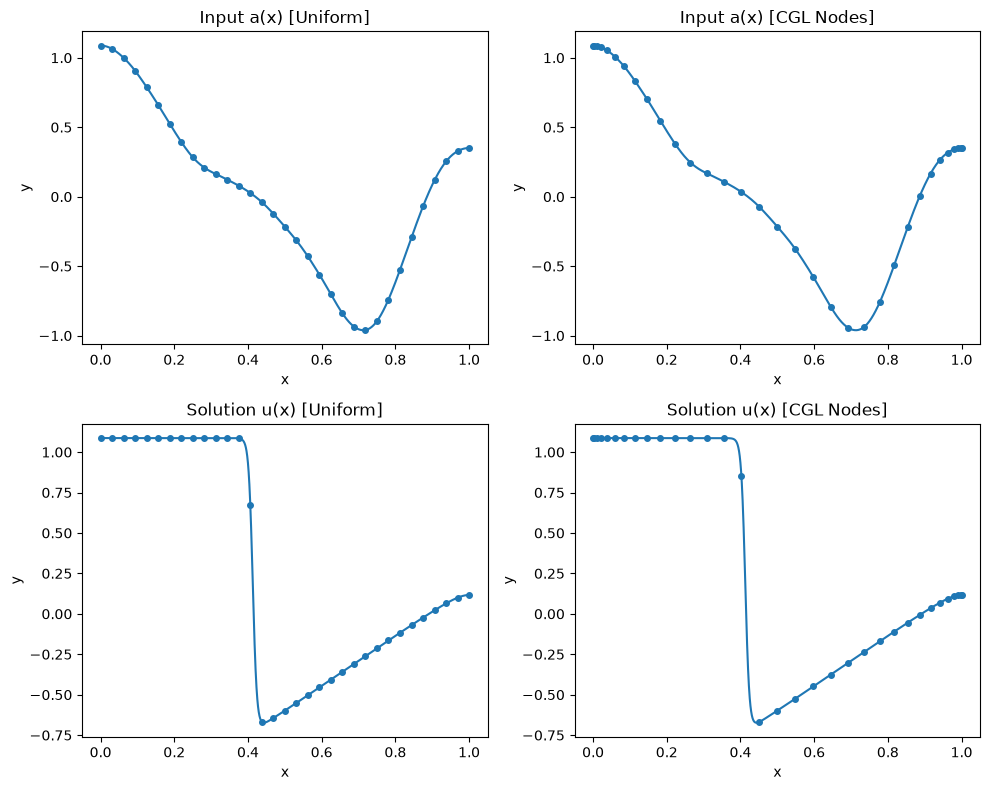

In [ ]:
data_type = DataType.BURGERS

data_config = data_config_map.get(data_type)
pth = data_config.pth 
cheby_pth = data_config.cheby_pth

data = torch.load(pth, mmap=True)
cheby_data = torch.load(cheby_pth, mmap=True)

unif_a, cgl_a = data["a"][0], cheby_data["a"][0]
unif_u, cgl_u = data["u"][0], cheby_data["u"][0]

print("unif_a shape: ", unif_a.shape)
print("cgl_a shape: ", cgl_a.shape)
print("unif_u shape: ", unif_u.shape)
print("cgl_u shape: ", cgl_u.shape)

visualize_cgl_vs_unif(data_type, unif_a=unif_a, unif_u=unif_u, cgl_a=cgl_a, cgl_u=cgl_u)